# Анализ и сравнение 12 Native LightRAG graphs

Этот notebook автоматически находит **12 завершённых Native-графов** в `runs/base`, загружает полные `graph_nodes.jsonl` и `graph_edges.jsonl` и сравнивает их на трёх уровнях:

1. **Размер и структура:** nodes, edges, density, degree, components, isolates, largest connected component.
2. **Содержание:** entity types, hubs, relation weights, document provenance.
3. **Согласованность моделей:** exact-label overlap, edge overlap, consensus entities и расхождения entity types.

Важно: overlap ниже — это сравнение нормализованных строковых labels (`strip + casefold + whitespace`), а не semantic entity resolution. Поэтому оно показывает строгое совпадение Native outputs и не подменяет ER-эксперимент.

Notebook ничего не изменяет в `runs/`. Таблицы и изображения сохраняются только в папке `Outputs/` рядом с notebook.

## 1. Настройка и автоматическое обнаружение experiment root

Notebook можно запускать из папки `Analysis`, из корня `experiment` или из JupyterLab с другим рабочим каталогом: путь к проекту определяется по наличию `configs/experiment.yaml` и `runs/base`.

In [1]:
from __future__ import annotations

import json
import math
import os
import re
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path


def find_experiment_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    # Также учитываем стандартное расположение относительно самого notebook.
    try:
        candidates.extend([Path.cwd() / "experiment", Path.cwd().parent / "experiment"])
    except Exception:
        pass
    for candidate in candidates:
        if (candidate / "configs" / "experiment.yaml").is_file() and (candidate / "runs" / "base").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Не найден experiment root: нужны configs/experiment.yaml и runs/base. "
        "Откройте notebook из Thesis/experiment/analysis или задайте PROJECT_ROOT вручную."
    )


PROJECT_ROOT = find_experiment_root(Path.cwd())
NOTEBOOK_DIR = PROJECT_ROOT / "analysis" / "4.1 Native Graph Construction"
OUTPUT_DIR = NOTEBOOK_DIR / "Outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Matplotlib не пытается писать cache в домашнюю папку.
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / ".matplotlib"))

import matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Okabe-Ito: colorblind-safe categorical palette used consistently in every figure.
OKABE_ITO = {
    "orange": "#E69F00",
    "sky_blue": "#56B4E9",
    "bluish_green": "#009E73",
    "yellow": "#F0E442",
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7",
    "black": "#000000",
}
OKABE_ITO_CYCLE = [
    OKABE_ITO["blue"], OKABE_ITO["orange"], OKABE_ITO["bluish_green"],
    OKABE_ITO["vermillion"], OKABE_ITO["sky_blue"],
    OKABE_ITO["reddish_purple"], OKABE_ITO["yellow"], OKABE_ITO["black"],
]
OKABE_ITO_SEQUENTIAL = LinearSegmentedColormap.from_list(
    "okabe_ito_sequential",
    ["#FFFFFF", OKABE_ITO["sky_blue"], OKABE_ITO["blue"], OKABE_ITO["black"]],
)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "cmr10",
    "font.size": 10,
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.prop_cycle": cycler(color=OKABE_ITO_CYCLE),
})

FAMILY_COLORS = {
    "qwen3.5": OKABE_ITO["blue"],
    "qwen3": OKABE_ITO["orange"],
    "gemma3": OKABE_ITO["bluish_green"],
}


def style_boxplot(boxplot, colors):
    for patch, color in zip(boxplot["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.72)
        patch.set_edgecolor(OKABE_ITO["black"])
    for key in ("whiskers", "caps", "medians"):
        for artist in boxplot[key]:
            artist.set_color(OKABE_ITO["black"])
            artist.set_linewidth(1.0)


def save_figure(fig, filename: str):
    path = FIGURES_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"OUTPUT_DIR:   {OUTPUT_DIR}")
print(f"NetworkX: {nx.__version__}; pandas: {pd.__version__}")

Matplotlib is building the font cache; this may take a moment.


PROJECT_ROOT: .
OUTPUT_DIR:   analysis/4.1 Native Graph Construction/Outputs
NetworkX: 3.6.1; pandas: 2.3.3


## 2. Инвентаризация 12 Native-графов

In [2]:
with (PROJECT_ROOT / "configs" / "experiment.yaml").open(encoding="utf-8") as f:
    experiment_config = yaml.safe_load(f)

configured_builders = experiment_config["builders"]
builder_meta = {row["key"]: row for row in configured_builders}
builder_order = [row["key"] for row in configured_builders]


def model_size_billions(display_name: str) -> float:
    match = re.search(r"([0-9]+(?:\.[0-9]+)?)\s*([BM])\b", display_name, flags=re.I)
    if not match:
        return np.nan
    value = float(match.group(1))
    return value if match.group(2).upper() == "B" else value / 1000.0


def active_graph_pair(base_dir: Path) -> tuple[Path, Path]:
    node_paths = [
        p for p in base_dir.glob("*/artifacts/graph_nodes.jsonl")
        if "backup" not in str(p).casefold() and "intermediate" not in str(p).casefold()
    ]
    edge_paths = [
        p for p in base_dir.glob("*/artifacts/graph_edges.jsonl")
        if "backup" not in str(p).casefold() and "intermediate" not in str(p).casefold()
    ]
    pairs = [(n, n.with_name("graph_edges.jsonl")) for n in node_paths if n.with_name("graph_edges.jsonl") in edge_paths]
    if len(pairs) != 1:
        raise RuntimeError(f"Ожидалась одна active node/edge pair в {base_dir}, найдено: {len(pairs)}")
    return pairs[0]


inventory_rows = []
for manifest_path in sorted((PROJECT_ROOT / "runs" / "base").glob("base_*/base_manifest.json")):
    with manifest_path.open(encoding="utf-8") as f:
        manifest = json.load(f)
    builder_key = manifest["builder_key"]
    if builder_key not in builder_meta:
        continue
    nodes_path, edges_path = active_graph_pair(manifest_path.parent)
    meta = builder_meta[builder_key]
    inventory_rows.append({
        "builder_key": builder_key,
        "model": meta["display_name"],
        "family": meta["family"],
        "parameters_b": model_size_billions(meta["display_name"]),
        "base_run_id": manifest["base_run_id"],
        "native_run_id": nodes_path.parent.parent.name,
        "nodes_path": nodes_path,
        "edges_path": edges_path,
        "nodes_mib": nodes_path.stat().st_size / 2**20,
        "edges_mib": edges_path.stat().st_size / 2**20,
    })

inventory = pd.DataFrame(inventory_rows)
inventory["builder_key"] = pd.Categorical(inventory["builder_key"], categories=builder_order, ordered=True)
inventory = inventory.sort_values("builder_key").reset_index(drop=True)

if len(inventory) != len(builder_order):
    found = set(inventory["builder_key"].astype(str))
    missing = [key for key in builder_order if key not in found]
    raise RuntimeError(f"Ожидалось {len(builder_order)} графов, найдено {len(inventory)}. Missing: {missing}")

display(
    inventory[["builder_key", "model", "family", "parameters_b", "base_run_id", "nodes_mib", "edges_mib"]]
    .style.format({"parameters_b": "{:.2f}", "nodes_mib": "{:.2f}", "edges_mib": "{:.2f}"})
    .background_gradient(subset=["nodes_mib", "edges_mib"], cmap="Blues")
)

,builder_key,model,family,parameters_b,base_run_id,nodes_mib,edges_mib
0,qwen35_0_8b,Qwen3.5 0.8B,qwen3.5,0.80,base_83aca3d6aa4f4a035bf5d21c,3.20,2.37
1,qwen35_2b,Qwen3.5 2B,qwen3.5,2.00,base_6ff2fb588647938593c42b5a,5.98,5.26
2,qwen35_4b,Qwen3.5 4B,qwen3.5,4.00,base_fade67868ef8d6d4b7d790eb,7.64,7.01
3,qwen35_9b,Qwen3.5 9B,qwen3.5,9.00,base_098496a4a666032d4809338b,6.93,6.86
4,qwen3_0_6b,Qwen3 0.6B,qwen3,0.60,base_084b5c3ad8d7434afbe4e74f,3.14,2.66
5,qwen3_1_7b,Qwen3 1.7B,qwen3,1.70,base_0d6955c37af628650e9654ec,4.34,4.77
6,qwen3_4b,Qwen3 4B,qwen3,4.00,base_97ba3cce02889beea444bd79,8.11,7.63
7,qwen3_8b,Qwen3 8B,qwen3,8.00,base_541d8b1af2513e6db17b19e0,14.36,2.64
8,gemma3_270m,Gemma 3 270M,gemma3,0.27,base_91358cb1f88dec176a28953b,1.09,0.17
9,gemma3_1b,Gemma 3 1B,gemma3,1.00,base_85df22828efa71c2b6754a25,2.68,1.77


## 3. Загрузка JSONL и построение NetworkX graphs

Native LightRAG graph интерпретируется как **undirected simple graph**, что соответствует используемому `NetworkXStorage`: degree и connected components считаются без направления. Исходные JSONL records сохраняются в DataFrame, включая provenance.

In [3]:
def read_jsonl(path: Path) -> list[dict]:
    records = []
    with path.open(encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSONL: {path}:{line_no}") from exc
    return records


def node_frame(records: list[dict]) -> pd.DataFrame:
    rows = []
    for rec in records:
        attrs = rec.get("attributes") or {}
        rows.append({
            "node_id": str(rec.get("node_id", "")),
            "entity_type": str(attrs.get("entity_type") or "UNKNOWN").strip().casefold(),
            "description": str(attrs.get("description") or ""),
            "document_ids": tuple(rec.get("document_ids") or []),
            "source_chunk_ids": tuple(rec.get("source_chunk_ids") or []),
        })
    return pd.DataFrame(rows)


def edge_frame(records: list[dict]) -> pd.DataFrame:
    rows = []
    for rec in records:
        attrs = rec.get("attributes") or {}
        rows.append({
            "edge_id": str(rec.get("edge_id", "")),
            "source": str(rec.get("source", "")),
            "target": str(rec.get("target", "")),
            "weight": float(attrs.get("weight", 1.0) or 1.0),
            "keywords": str(attrs.get("keywords") or ""),
            "description": str(attrs.get("description") or ""),
            "document_ids": tuple(rec.get("document_ids") or []),
            "source_chunk_ids": tuple(rec.get("source_chunk_ids") or []),
        })
    return pd.DataFrame(rows)


graphs = {}
for row in inventory.itertuples(index=False):
    nodes = node_frame(read_jsonl(row.nodes_path))
    edges = edge_frame(read_jsonl(row.edges_path))
    graph = nx.Graph()
    graph.add_nodes_from(nodes["node_id"])
    graph.add_edges_from(edges[["source", "target"]].itertuples(index=False, name=None))
    degree = dict(graph.degree())
    nodes["degree"] = nodes["node_id"].map(degree).fillna(0).astype(int)
    nodes["document_count"] = nodes["document_ids"].map(len)
    nodes["chunk_count"] = nodes["source_chunk_ids"].map(len)
    edges["document_count"] = edges["document_ids"].map(len)
    edges["chunk_count"] = edges["source_chunk_ids"].map(len)
    graphs[str(row.builder_key)] = {
        "model": row.model,
        "family": row.family,
        "parameters_b": row.parameters_b,
        "nodes": nodes,
        "edges": edges,
        "graph": graph,
    }

print(f"Loaded {len(graphs)} graphs")
print(f"Total nodes: {sum(len(v['nodes']) for v in graphs.values()):,}")
print(f"Total edges: {sum(len(v['edges']) for v in graphs.values()):,}")

Loaded 12 graphs
Total nodes: 65,699
Total edges: 45,453


## 4. Integrity checks и основная сравнительная таблица

In [4]:
def canonical_edge(source: str, target: str) -> tuple[str, str]:
    return tuple(sorted((source, target)))


summary_rows = []
quality_rows = []

for key in builder_order:
    item = graphs[key]
    nodes, edges, graph = item["nodes"], item["edges"], item["graph"]
    node_ids = set(nodes["node_id"])
    dangling = (~edges["source"].isin(node_ids) | ~edges["target"].isin(node_ids)).sum()
    duplicate_edges = edges.apply(lambda r: canonical_edge(r["source"], r["target"]), axis=1).duplicated().sum()
    components = list(nx.connected_components(graph)) if graph.number_of_nodes() else []
    largest_component = max((len(c) for c in components), default=0)
    n = graph.number_of_nodes()
    m = graph.number_of_edges()
    isolates = nx.number_of_isolates(graph)
    summary_rows.append({
        "builder_key": key,
        "model": item["model"],
        "family": item["family"],
        "parameters_b": item["parameters_b"],
        "nodes": n,
        "edges": m,
        "avg_degree": (2 * m / n) if n else np.nan,
        "median_degree": nodes["degree"].median(),
        "max_degree": nodes["degree"].max(),
        "density": nx.density(graph),
        "transitivity": nx.transitivity(graph),
        "components": len(components),
        "largest_component": largest_component,
        "largest_component_share": largest_component / n if n else np.nan,
        "isolates": isolates,
        "isolate_share": isolates / n if n else np.nan,
        "mean_docs_per_node": nodes["document_count"].mean(),
        "mean_chunks_per_node": nodes["chunk_count"].mean(),
    })
    quality_rows.append({
        "builder_key": key,
        "duplicate_node_ids": int(nodes["node_id"].duplicated().sum()),
        "duplicate_undirected_edges": int(duplicate_edges),
        "dangling_edges": int(dangling),
        "self_loops": int(nx.number_of_selfloops(graph)),
        "empty_node_ids": int(nodes["node_id"].eq("").sum()),
        "empty_edge_endpoints": int(edges["source"].eq("").sum() + edges["target"].eq("").sum()),
    })

summary = pd.DataFrame(summary_rows).set_index("builder_key").loc[builder_order].reset_index()
quality = pd.DataFrame(quality_rows).set_index("builder_key").loc[builder_order].reset_index()

display(
    summary.style
    .format({
        "parameters_b": "{:.2f}", "nodes": "{:,}", "edges": "{:,}",
        "avg_degree": "{:.2f}", "median_degree": "{:.1f}", "max_degree": "{:.0f}",
        "density": "{:.6f}", "transitivity": "{:.4f}",
        "largest_component_share": "{:.1%}", "isolate_share": "{:.1%}",
        "mean_docs_per_node": "{:.2f}", "mean_chunks_per_node": "{:.2f}",
    })
    .background_gradient(subset=["nodes", "edges", "avg_degree", "largest_component_share"], cmap="YlGnBu")
)
display(Markdown("**Integrity checks (ожидаемые значения — нули):**"))
display(quality.style.background_gradient(subset=quality.columns[1:].tolist(), cmap="Reds"))

,builder_key,model,family,parameters_b,nodes,edges,avg_degree,median_degree,max_degree,density,transitivity,components,largest_component,largest_component_share,isolates,isolate_share,mean_docs_per_node,mean_chunks_per_node
0,qwen35_0_8b,Qwen3.5 0.8B,qwen3.5,0.80,"3,029","2,054",1.36,1.0,52,0.000448,0.0450,1226,774,25.6%,956,31.6%,1.20,1.35
1,qwen35_2b,Qwen3.5 2B,qwen3.5,2.00,"5,825","4,690",1.61,1.0,93,0.000276,0.0388,1826,2529,43.4%,1154,19.8%,1.22,1.37
2,qwen35_4b,Qwen3.5 4B,qwen3.5,4.00,"7,256","6,263",1.73,1.0,101,0.000238,0.0255,2020,3766,51.9%,1321,18.2%,1.28,1.49
3,qwen35_9b,Qwen3.5 9B,qwen3.5,9.00,"6,383","6,085",1.91,1.0,109,0.000299,0.0267,1458,3854,60.4%,979,15.3%,1.30,1.54
4,qwen3_0_6b,Qwen3 0.6B,qwen3,0.60,"3,092","2,447",1.58,1.0,115,0.000512,0.0319,1044,1543,49.9%,809,26.2%,1.27,1.44
5,qwen3_1_7b,Qwen3 1.7B,qwen3,1.70,"4,404","4,416",2.01,1.0,130,0.000455,0.0680,1161,2474,56.2%,950,21.6%,1.22,1.39
6,qwen3_4b,Qwen3 4B,qwen3,4.00,"7,786","6,872",1.77,1.0,151,0.000227,0.0265,2367,4624,59.4%,2138,27.5%,1.22,1.38
7,qwen3_8b,Qwen3 8B,qwen3,8.00,"13,441","2,422",0.36,0.0,62,0.000027,0.0561,11562,1327,9.9%,11414,84.9%,1.20,1.33
8,gemma3_270m,Gemma 3 270M,gemma3,0.27,"1,017",158,0.31,0.0,7,0.000306,0.1250,864,8,0.8%,774,76.1%,1.26,1.40
9,gemma3_1b,Gemma 3 1B,gemma3,1.00,"2,887","1,688",1.17,1.0,38,0.000405,0.0786,1460,637,22.1%,1309,45.3%,1.21,1.35


**Integrity checks (ожидаемые значения — нули):**

,builder_key,duplicate_node_ids,duplicate_undirected_edges,dangling_edges,self_loops,empty_node_ids,empty_edge_endpoints
0,qwen35_0_8b,0,0,0,0,0,0
1,qwen35_2b,0,0,0,0,0,0
2,qwen35_4b,0,0,0,0,0,0
3,qwen35_9b,0,0,0,0,0,0
4,qwen3_0_6b,0,0,0,0,0,0
5,qwen3_1_7b,0,0,0,0,0,0
6,qwen3_4b,0,0,0,0,0,0
7,qwen3_8b,0,0,0,0,0,0
8,gemma3_270m,0,0,0,0,0,0
9,gemma3_1b,0,0,0,0,0,0


## 5. Размер и глобальная структура графов

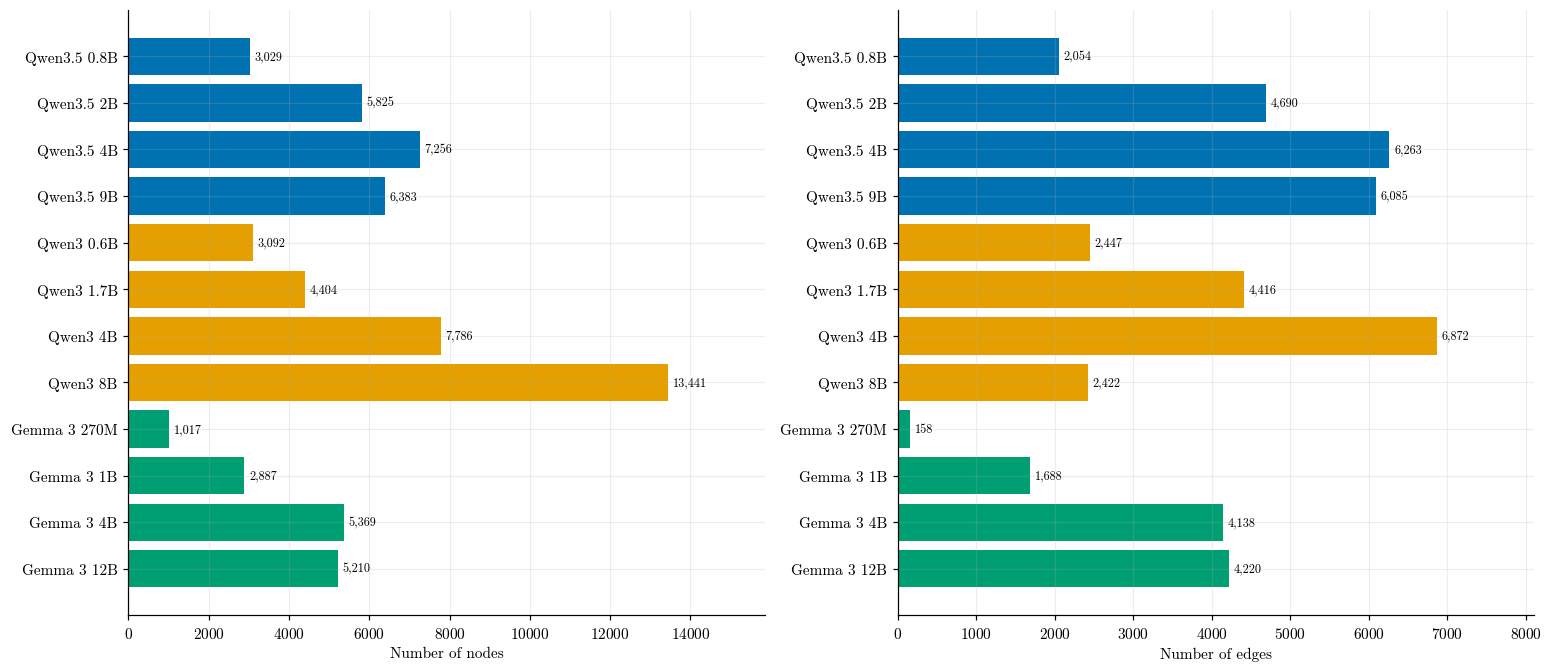

PosixPath('analysis/4.1 Native Graph Construction/Outputs/figures/01_graph_size.png')

In [5]:
plot_df = summary.copy()
colors = plot_df["family"].map(FAMILY_COLORS)
y = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, metric, xlabel in zip(axes, ["nodes", "edges"], ["Number of nodes", "Number of edges"]):
    bars = ax.barh(y, plot_df[metric], color=colors)
    ax.set_yticks(y, plot_df["model"])
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.bar_label(bars, labels=[f"{v:,}" for v in plot_df[metric]], padding=3, fontsize=8)
    ax.set_xlim(0, plot_df[metric].max() * 1.18)
save_figure(fig, "01_graph_size.png")

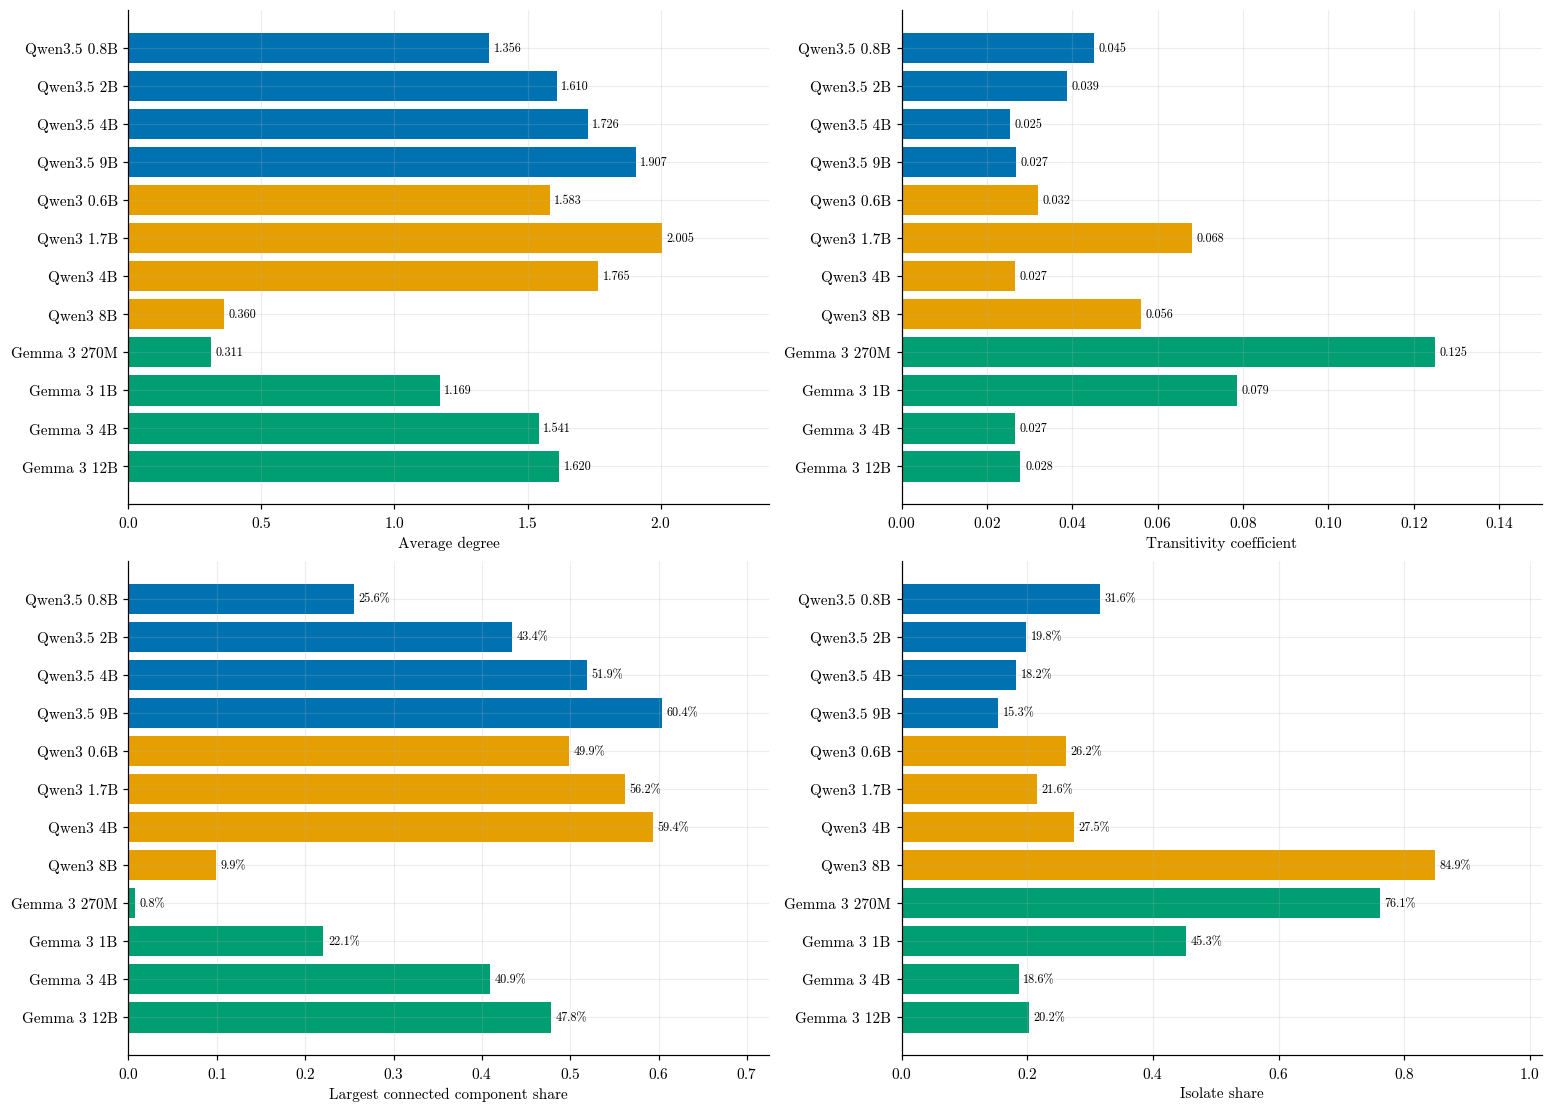

PosixPath('analysis/4.1 Native Graph Construction/Outputs/figures/02_structural_metrics.png')

In [6]:
metrics = [
    ("avg_degree", "Average degree"),
    ("transitivity", "Transitivity coefficient"),
    ("largest_component_share", "Largest connected component share"),
    ("isolate_share", "Isolate share"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for ax, (metric, xlabel) in zip(axes.flat, metrics):
    bars = ax.barh(y, plot_df[metric], color=colors)
    ax.set_yticks(y, plot_df["model"])
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    if metric.endswith("share"):
        labels = [f"{v:.1%}" for v in plot_df[metric]]
    else:
        labels = [f"{v:.3f}" for v in plot_df[metric]]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=8)
    ax.set_xlim(0, max(plot_df[metric].max() * 1.20, 1e-9))
save_figure(fig, "02_structural_metrics.png")

## 6. Связь model size и graph output

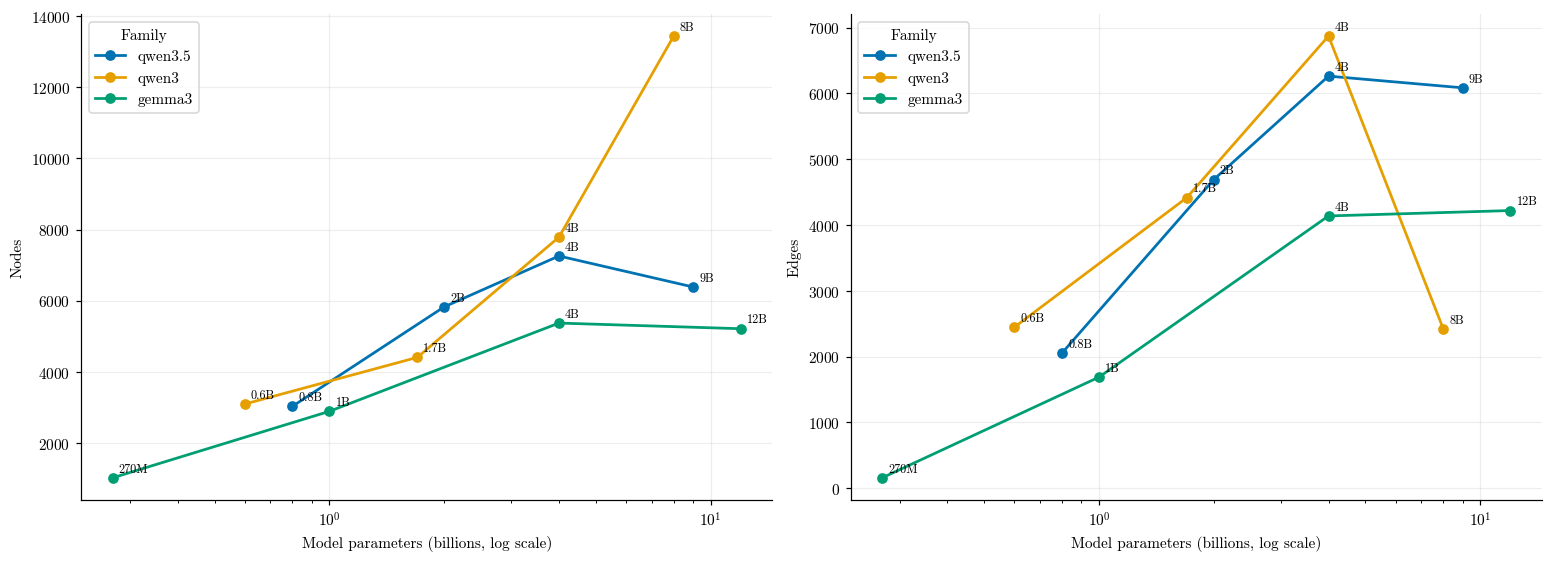

PosixPath('analysis/4.1 Native Graph Construction/Outputs/figures/03_model_size_vs_graph_size.png')

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, metric, ylabel in zip(axes, ["nodes", "edges"], ["Nodes", "Edges"]):
    for family, group in plot_df.groupby("family", sort=False):
        group = group.sort_values("parameters_b")
        ax.plot(
            group["parameters_b"], group[metric], marker="o", linewidth=1.8,
            color=FAMILY_COLORS[family], label=family,
        )
        for row in group.itertuples(index=False):
            ax.annotate(row.model.replace("Gemma 3 ", "").replace("Qwen3.5 ", "").replace("Qwen3 ", ""),
                        (row.parameters_b, getattr(row, metric)), xytext=(4, 4),
                        textcoords="offset points", fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("Model parameters (billions, log scale)")
    ax.set_ylabel(ylabel)
    ax.legend(title="Family")
save_figure(fig, "03_model_size_vs_graph_size.png")

## 7. Entity types: состав графов

,entity_type,all_graph_occurrences
0,person,"14,457"
1,organization,"12,782"
2,concept,"10,698"
3,content,"5,453"
4,unknown,"5,343"
5,artifact,"4,247"
6,event,"3,724"
7,location,"3,396"
8,method,"1,277"
9,data,"1,257"


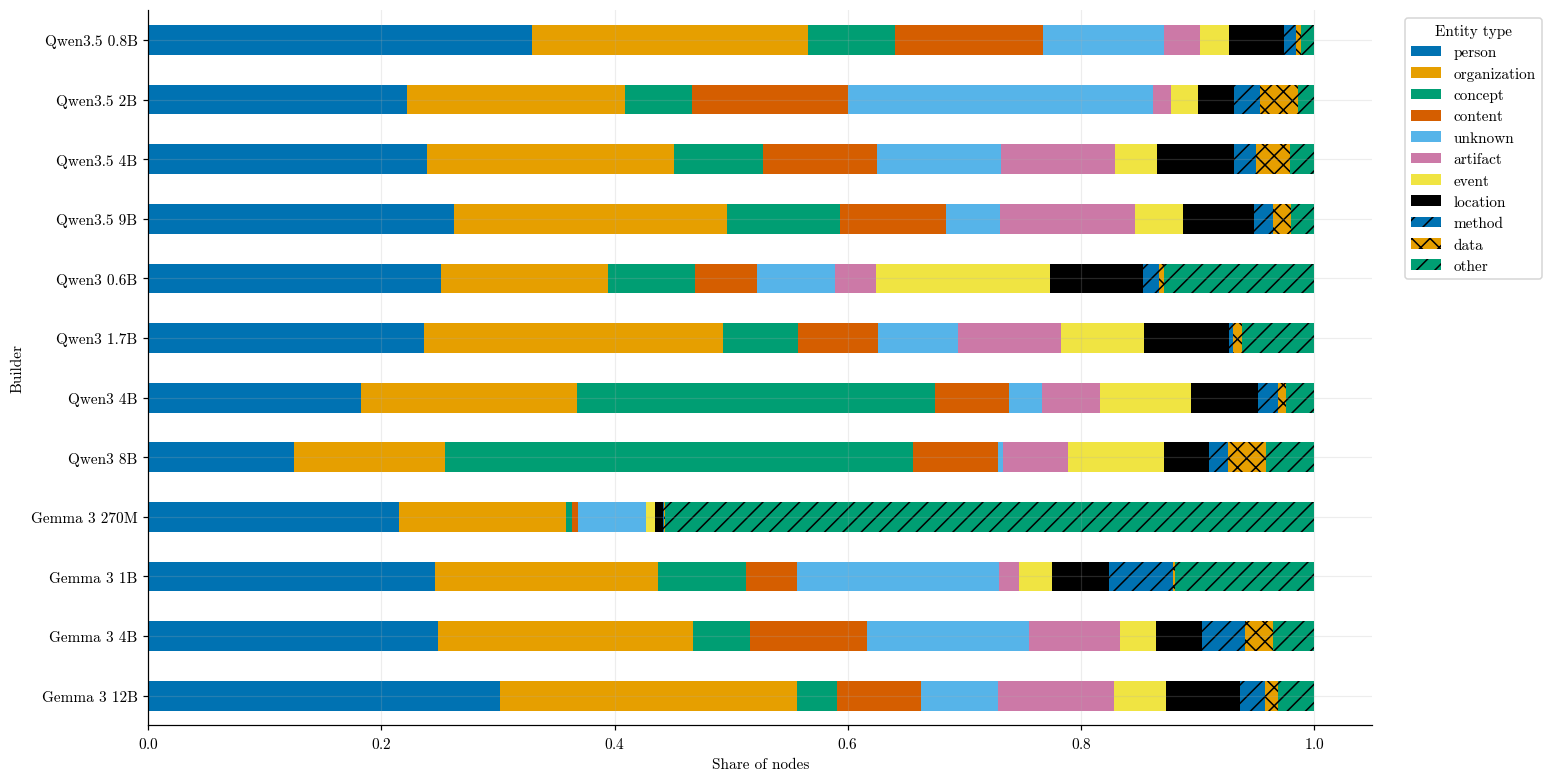

PosixPath('analysis/4.1 Native Graph Construction/Outputs/figures/04_entity_type_composition.png')

In [8]:
global_type_counts = Counter()
per_graph_type_counts = {}
for key in builder_order:
    counts = Counter(graphs[key]["nodes"]["entity_type"])
    per_graph_type_counts[key] = counts
    global_type_counts.update(counts)

TOP_TYPE_COUNT = 10
top_types = [name for name, _ in global_type_counts.most_common(TOP_TYPE_COUNT)]
type_rows = []
for key in builder_order:
    counts = per_graph_type_counts[key]
    total = sum(counts.values())
    row = {"builder_key": key}
    for entity_type in top_types:
        row[entity_type] = counts.get(entity_type, 0) / total
    row["other"] = 1 - sum(row[t] for t in top_types)
    type_rows.append(row)

type_shares = pd.DataFrame(type_rows).set_index("builder_key").loc[builder_order]
type_counts_table = pd.DataFrame(
    [{"entity_type": t, "all_graph_occurrences": c} for t, c in global_type_counts.most_common(25)]
)

display(type_counts_table.style.format({"all_graph_occurrences": "{:,}"}))

fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)
type_colors = [OKABE_ITO_CYCLE[i % len(OKABE_ITO_CYCLE)] for i in range(type_shares.shape[1])]
type_shares.plot(kind="barh", stacked=True, ax=ax, color=type_colors)
# Repeated Okabe-Ito colors (categories 9+) are additionally distinguished by hatching.
for i, container in enumerate(ax.containers):
    if i >= len(OKABE_ITO_CYCLE):
        for patch in container.patches:
            patch.set_hatch("//" if i % 2 == 0 else "xx")
ax.invert_yaxis()
ax.set_yticklabels([graphs[key]["model"] for key in builder_order])
ax.set_xlabel("Share of nodes")
ax.set_ylabel("Builder")
ax.legend(title="Entity type", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure(fig, "04_entity_type_composition.png")

## 8. Degree distributions и hubs

,builder_key,mean,median,p90,p95,p99,max
0,qwen35_0_8b,1.36,1.00,3.00,4.00,10.00,52.00
1,qwen35_2b,1.61,1.00,3.00,5.00,13.00,93.00
2,qwen35_4b,1.73,1.00,3.00,5.00,14.00,101.00
3,qwen35_9b,1.91,1.00,4.00,6.00,16.00,109.00
4,qwen3_0_6b,1.58,1.00,3.00,5.00,15.00,115.00
5,qwen3_1_7b,2.01,1.00,4.00,7.00,17.00,130.00
6,qwen3_4b,1.77,1.00,3.00,5.00,20.00,151.00
7,qwen3_8b,0.36,0.00,1.00,2.00,6.00,62.00
8,gemma3_270m,0.31,0.00,1.00,1.00,3.00,7.00
9,gemma3_1b,1.17,1.00,3.00,4.00,10.00,38.00


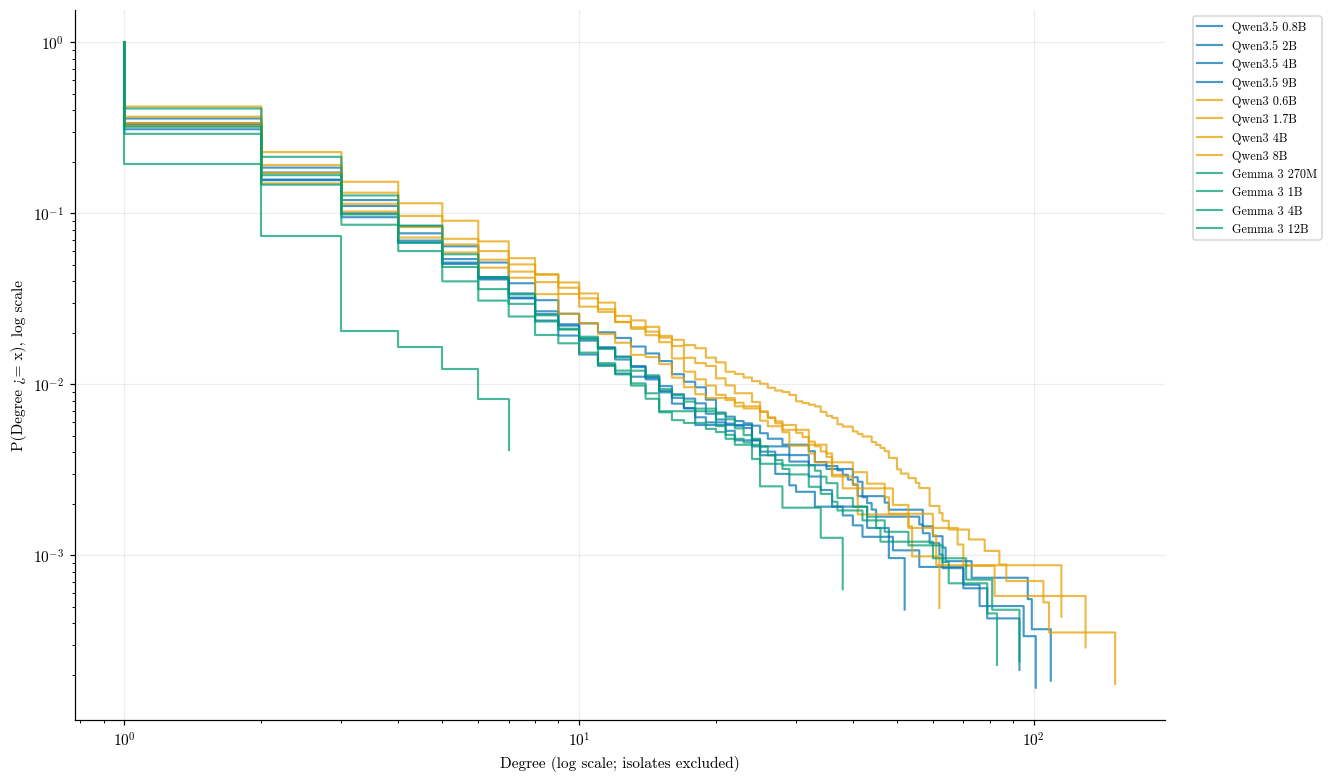

PosixPath('analysis/4.1 Native Graph Construction/Outputs/figures/05_degree_ccdf.png')

In [9]:
degree_rows = []
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for key in builder_order:
    item = graphs[key]
    degrees = item["nodes"]["degree"].to_numpy()
    positive = np.sort(degrees[degrees > 0])
    if len(positive):
        ccdf = np.arange(len(positive), 0, -1) / len(positive)
        ax.step(positive, ccdf, where="post", alpha=0.72, linewidth=1.4,
                color=FAMILY_COLORS[item["family"]], label=item["model"])
    degree_rows.append({
        "builder_key": key,
        "mean": degrees.mean(),
        "median": np.median(degrees),
        "p90": np.quantile(degrees, 0.90),
        "p95": np.quantile(degrees, 0.95),
        "p99": np.quantile(degrees, 0.99),
        "max": degrees.max(),
    })

degree_stats = pd.DataFrame(degree_rows).set_index("builder_key").loc[builder_order].reset_index()
display(degree_stats.style.format({c: "{:.2f}" for c in ["mean", "median", "p90", "p95", "p99", "max"]}))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Degree (log scale; isolates excluded)")
ax.set_ylabel("P(Degree >= x), log scale")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
save_figure(fig, "05_degree_ccdf.png")

### Детальный просмотр одного builder

Измените `SELECTED_BUILDER` на любой ключ из inventory. `TOP_K` управляет числом hubs в таблице, а `MAX_NETWORK_NODES` — размером визуализируемого подграфа.

In [10]:
SELECTED_BUILDER = "qwen35_4b"
TOP_K = 25
MAX_NETWORK_NODES = 140

if SELECTED_BUILDER not in graphs:
    raise KeyError(f"Unknown builder: {SELECTED_BUILDER}. Available: {list(graphs)}")

selected = graphs[SELECTED_BUILDER]
selected_nodes = selected["nodes"].sort_values(["degree", "node_id"], ascending=[False, True])
hubs = selected_nodes[[
    "node_id", "entity_type", "degree", "document_count", "chunk_count", "description"
]].head(TOP_K).reset_index(drop=True)

display(Markdown(f"**{selected['model']} — top {TOP_K} hubs**"))
display(hubs.style.background_gradient(subset=["degree", "document_count", "chunk_count"], cmap="YlOrRd"))

**Qwen3.5 4B — top 25 hubs**

,node_id,entity_type,degree,document_count,chunk_count,description
0,Google,organization,101,25,45,"Google is a prominent Silicon Valley multinational and the parent company of Alphabet Inc., renowned as a global technology giant that provides search engine services, consumer hardware such as the Pixel series and A-Series earbuds, social networking platforms, artificial intelligence solutions, and advertising-driven ecosystems including Android, Google Play Store, and Google Pay. As a major player in the tech industry, Google distributes the Android operating system as open source while competing with organizations like OpenAI by developing proprietary large language models (LLMs) and acquiring DeepMind in 2014 to enhance its machine learning capabilities. The company is currently involved in multiple legal challenges, including class action lawsuits concerning app store commissions, sideloading security risks, content moderation issues, and antitrust concerns regarding illegal monopoly practices over Android app distribution and payment systems found by a US jury; it has also faced a federal judge throwing out a $32.5 million win against Sonos and is being sued by Epic Games regarding alleged monopolistic practices. Beyond its core search capabilities, Google operates as a major American technology company working on next-generation AI systems with processing capacities exceeding 10^26 petaflops, subject to new enforcement thresholds, while simultaneously calling for more regulation of artificial intelligence despite not selecting ChatGPT as its app of the year in 2023. It is attracted to India's large domestic consumer market and is involved in the AI landscape through its subsidiary Gradient Ventures, which invested in Tidalflow. The company manufactures specific hardware including Pixel Buds Pro and has made Passkeys the default sign-in method for all users. In recent years, it has experienced significant workforce reductions, including confirmed layoffs affecting various divisions such as its news division and consumer support staff. Despite these adjustments amidst complex business relationships and regulatory pressure from antitrust investigations involving Apple users, Google remains unable to effectively monitor and take down generated content due to the volume and sophistication of the threat. The parent company of Alphabet reported mixed results with revenue climbing but cloud division underperforming expectations. Additionally, there is a specific context where Google served as an organization where Dalia Awad interned and offered a full-time job in Paris. While one description characterizes it simply as a brand offering big-ticket items available at discounted prices during Black Friday promotions, the primary entity described throughout these entries is the comprehensive technology corporation detailed above."
1,OpenAI,organization,95,13,33,"OpenAI is an American artificial intelligence research organization founded in late 2015 by Sam Altman and Elon Musk, originally established as a nonprofit entity that has since evolved into a for-profit technology company headquartered in San Francisco. Valued at approximately $86 billion, the organization is globally recognized for its proprietary large language models and viral products including ChatGPT, GPT-4, GPT-4 Turbo, DALL-E image generation, and DALL-E 3. It operates within a complex regulatory environment, facing scrutiny regarding data privacy, defamation issues in Italy, and legal disputes over user data usage while maintaining mobile applications for its chatbot service. Key figures associated with the company include Sam Altman, Elon Musk, Brockman, and Chelsea Voss, who have contributed to core model development and strategic direction. The organization has expanded its reach by licensing news content from partners such as Axel Springer for training purposes and continues to innovate through general availability updates. OpenAI currently navigates significant

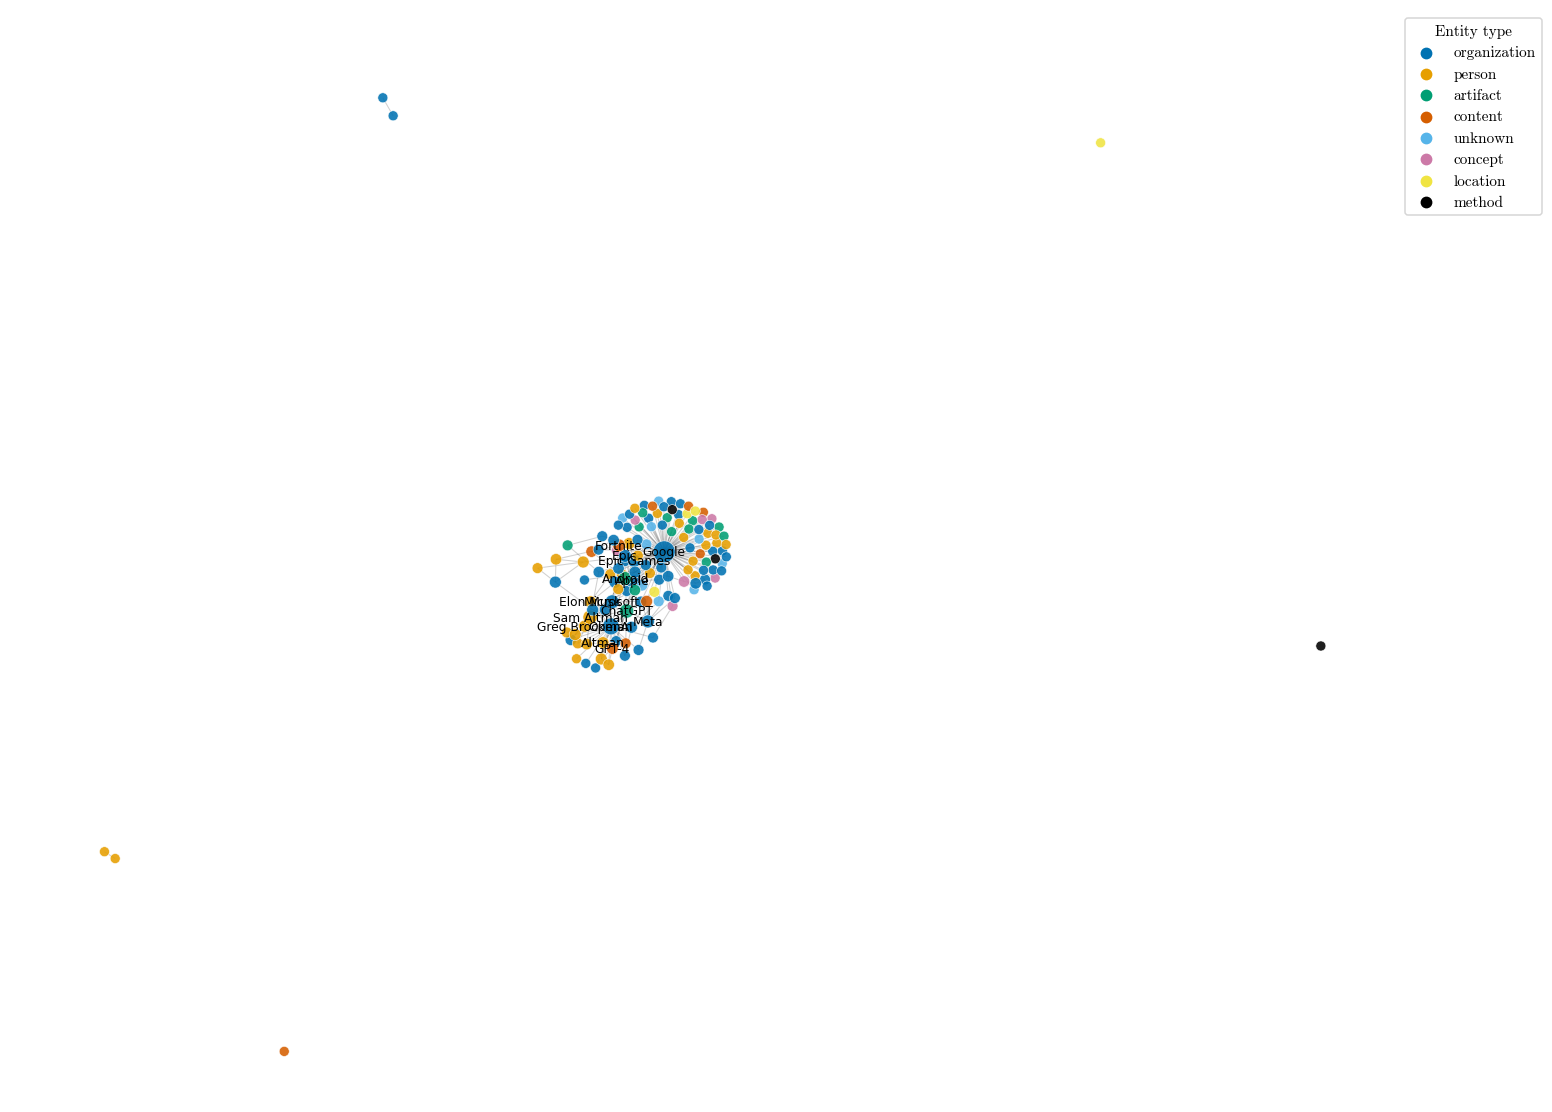

PosixPath('analysis/4.1 Native Graph Construction/Outputs/figures/06_sample_network_qwen35_4b.png')

In [11]:
graph = selected["graph"]
seed_nodes = hubs["node_id"].head(20).tolist()
chosen = set(seed_nodes)

# Добавляем наиболее связных соседей hubs до лимита.
for seed_node in seed_nodes:
    neighbours = sorted(graph.neighbors(seed_node), key=lambda n: graph.degree(n), reverse=True)
    for neighbour in neighbours:
        if len(chosen) >= MAX_NETWORK_NODES:
            break
        chosen.add(neighbour)
    if len(chosen) >= MAX_NETWORK_NODES:
        break

subgraph = graph.subgraph(chosen).copy()
degree_sub = dict(subgraph.degree())
type_map = selected["nodes"].set_index("node_id")["entity_type"].to_dict()
top_sub_types = [t for t, _ in Counter(type_map.get(n, "unknown") for n in subgraph).most_common(8)]
type_color = {t: OKABE_ITO_CYCLE[i % len(OKABE_ITO_CYCLE)] for i, t in enumerate(top_sub_types)}
node_colors = [type_color.get(type_map.get(n, "unknown"), OKABE_ITO["black"]) for n in subgraph]
node_sizes = [25 + 18 * math.sqrt(max(degree_sub[n], 1)) for n in subgraph]

pos = nx.spring_layout(subgraph, seed=42, iterations=80, k=1 / math.sqrt(max(len(subgraph), 1)))
fig, ax = plt.subplots(figsize=(14, 10), constrained_layout=True)
nx.draw_networkx_edges(subgraph, pos, ax=ax, alpha=0.18, width=0.7, edge_color=OKABE_ITO["black"])
nx.draw_networkx_nodes(subgraph, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
                       alpha=0.88, linewidths=0.4, edgecolors="white")
label_nodes = sorted(subgraph, key=lambda n: degree_sub[n], reverse=True)[:15]
nx.draw_networkx_labels(subgraph, pos, labels={n: n for n in label_nodes}, ax=ax, font_size=8)
for entity_type, color in type_color.items():
    ax.scatter([], [], color=color, label=entity_type, s=45)
ax.legend(title="Entity type", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.axis("off")
save_figure(fig, f"06_sample_network_{SELECTED_BUILDER}.png")

## 9. Exact entity-label overlap между моделями

Labels нормализуются только технически: регистр, крайние пробелы и повторяющиеся whitespace. Например, `OpenAI` и ` openai ` совпадут, но `OpenAI Inc.` и `OpenAI` останутся разными.

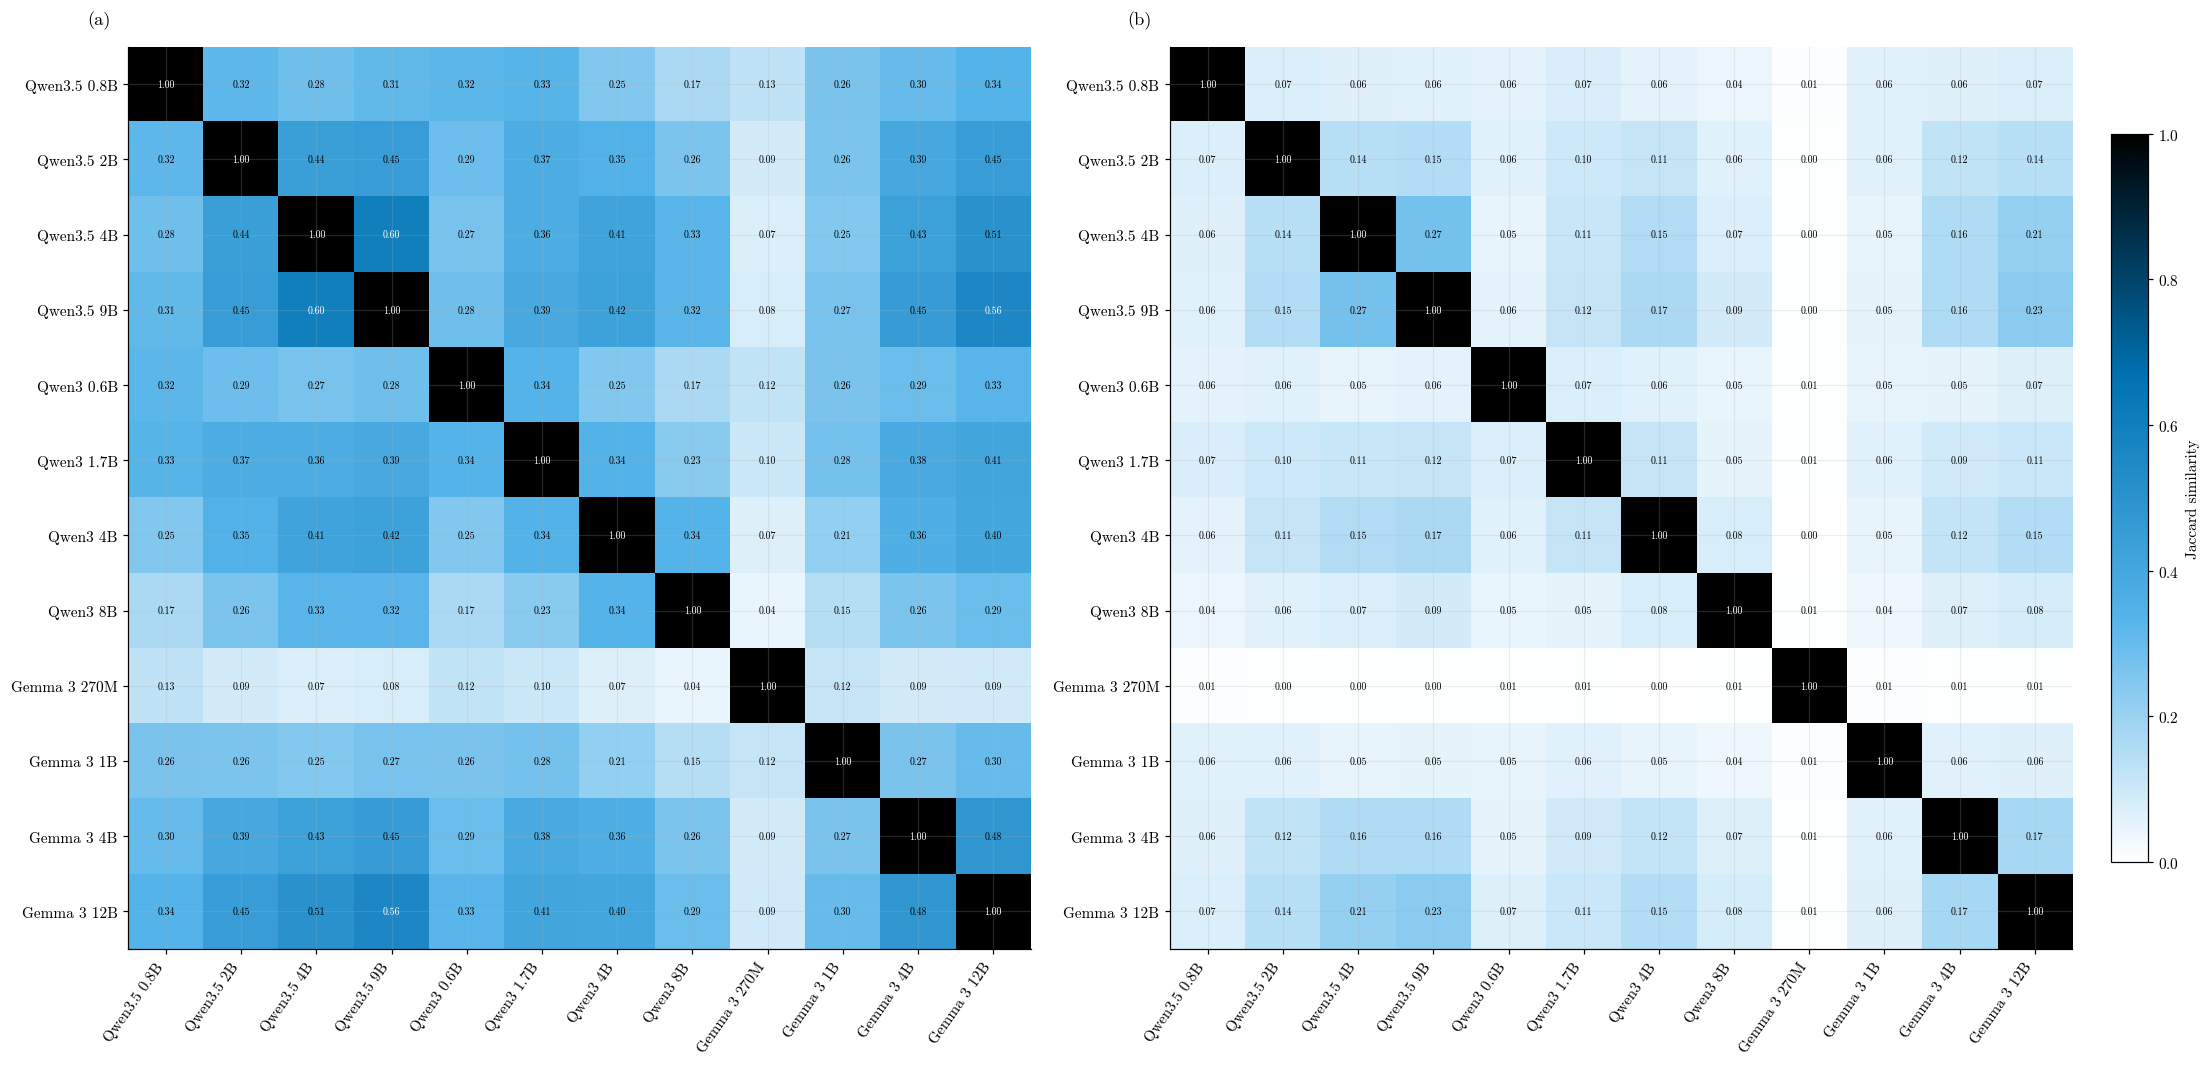

PosixPath('analysis/4.1 Native Graph Construction/Outputs/figures/07_node_edge_jaccard.png')

In [12]:
def normalize_label(value: str) -> str:
    return re.sub(r"\s+", " ", str(value).strip()).casefold()


def jaccard(a: set, b: set) -> float:
    union = a | b
    return len(a & b) / len(union) if union else 1.0


node_sets = {
    key: {normalize_label(node_id) for node_id in graphs[key]["nodes"]["node_id"] if normalize_label(node_id)}
    for key in builder_order
}
edge_sets = {}
for key in builder_order:
    pairs = set()
    for source, target in graphs[key]["edges"][["source", "target"]].itertuples(index=False, name=None):
        a, b = normalize_label(source), normalize_label(target)
        if a and b:
            pairs.add(tuple(sorted((a, b))))
    edge_sets[key] = pairs


def pairwise_jaccard(sets_by_key: dict[str, set]) -> pd.DataFrame:
    matrix = pd.DataFrame(index=builder_order, columns=builder_order, dtype=float)
    for left in builder_order:
        for right in builder_order:
            matrix.loc[left, right] = jaccard(sets_by_key[left], sets_by_key[right])
    return matrix


node_jaccard = pairwise_jaccard(node_sets)
edge_jaccard = pairwise_jaccard(edge_sets)


def draw_similarity_panel(ax, matrix: pd.DataFrame, panel_label: str):
    image = ax.imshow(matrix.to_numpy(), vmin=0, vmax=1, cmap=OKABE_ITO_SEQUENTIAL)
    model_labels = [graphs[key]["model"] for key in matrix.index]
    ax.set_xticks(range(len(matrix)), model_labels, rotation=55, ha="right")
    ax.set_yticks(range(len(matrix)), model_labels)
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            value = matrix.iat[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                    color="white" if value > 0.55 else "black", fontsize=6.5)
    ax.text(-0.02, 1.02, panel_label, transform=ax.transAxes,
            ha="right", va="bottom", fontsize=12, fontweight="bold")
    return image


fig, axes = plt.subplots(1, 2, figsize=(20, 9.5), constrained_layout=True)
image = draw_similarity_panel(axes[0], node_jaccard, "(a)")
draw_similarity_panel(axes[1], edge_jaccard, "(b)")
fig.colorbar(image, ax=axes, label="Jaccard similarity", shrink=0.78, pad=0.02)
save_figure(fig, "07_node_edge_jaccard.png")

## 10. Consensus entities, model-specific entities и type disagreements

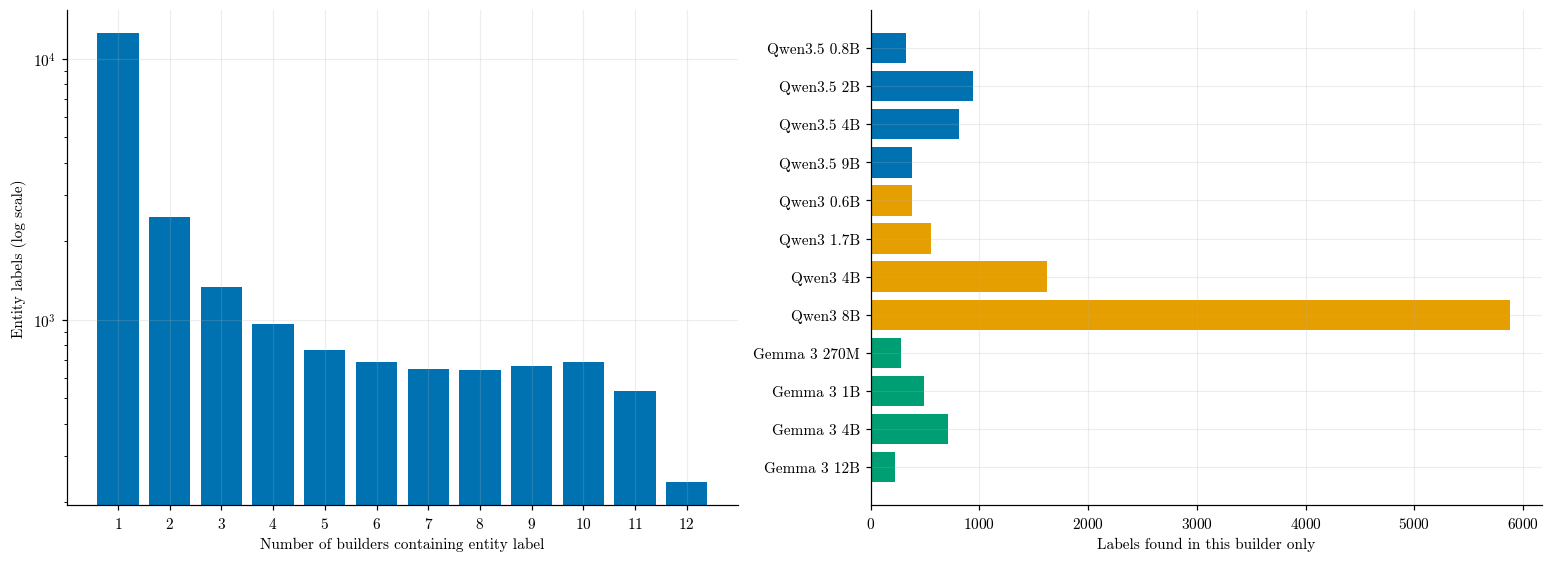

**Entities present in all 12 Native graphs:**

,display_label,builder_count
0,1989,12
1,49ers,12
2,AI,12
3,Activision Blizzard,12
4,Adam Yedidia,12
...,...,...
95,Gaza,12
96,Geno Smith,12
97,GitHub,12
98,Google,12


In [13]:
entity_builders = defaultdict(set)
entity_original_labels = defaultdict(Counter)
entity_types_by_builder = defaultdict(lambda: defaultdict(set))

for key in builder_order:
    nodes = graphs[key]["nodes"]
    for row in nodes.itertuples(index=False):
        normalized = normalize_label(row.node_id)
        if not normalized:
            continue
        entity_builders[normalized].add(key)
        entity_original_labels[normalized][row.node_id] += 1
        entity_types_by_builder[normalized][key].add(row.entity_type)

consensus_rows = []
for entity, builders in entity_builders.items():
    consensus_rows.append({
        "normalized_entity": entity,
        "display_label": entity_original_labels[entity].most_common(1)[0][0],
        "builder_count": len(builders),
        "builders": ", ".join(key for key in builder_order if key in builders),
    })
consensus = pd.DataFrame(consensus_rows).sort_values(
    ["builder_count", "display_label"], ascending=[False, True]
).reset_index(drop=True)

coverage_distribution = consensus["builder_count"].value_counts().sort_index().reindex(range(1, 13), fill_value=0)
unique_counts = {
    key: sum(1 for entity in node_sets[key] if len(entity_builders[entity]) == 1)
    for key in builder_order
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].bar(coverage_distribution.index, coverage_distribution.values, color=OKABE_ITO["blue"])
axes[0].set_yscale("log")
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel("Number of builders containing entity label")
axes[0].set_ylabel("Entity labels (log scale)")

axes[1].barh([graphs[key]["model"] for key in builder_order], [unique_counts[k] for k in builder_order],
                 color=[FAMILY_COLORS[graphs[k]["family"]] for k in builder_order])
axes[1].invert_yaxis()
axes[1].set_xlabel("Labels found in this builder only")
save_figure(fig, "09_entity_consensus.png")

display(Markdown("**Entities present in all 12 Native graphs:**"))
display(consensus.query("builder_count == 12")[["display_label", "builder_count"]].head(100))

In [14]:
disagreement_rows = []
for entity, per_builder in entity_types_by_builder.items():
    all_types = sorted({t for types in per_builder.values() for t in types})
    if len(per_builder) >= 2 and len(all_types) > 1:
        disagreement_rows.append({
            "display_label": entity_original_labels[entity].most_common(1)[0][0],
            "builder_count": len(per_builder),
            "type_count": len(all_types),
            "types": ", ".join(all_types),
            "assignment_by_builder": "; ".join(
                f"{key}={','.join(sorted(per_builder[key]))}" for key in builder_order if key in per_builder
            ),
        })

type_disagreements = pd.DataFrame(disagreement_rows)
if not type_disagreements.empty:
    type_disagreements = type_disagreements.sort_values(
        ["builder_count", "type_count", "display_label"], ascending=[False, False, True]
    ).reset_index(drop=True)

display(Markdown(f"**Exact labels with inconsistent entity types: {len(type_disagreements):,}**"))
display(type_disagreements.head(100))

**Exact labels with inconsistent entity types: 5,365**

,display_label,builder_count,type_count,types,assignment_by_builder
0,Fighter,12,8,"concept, content, melee, meleeclass, method, organization, person, unknown",qwen35_0_8b=method; qwen35_2b=unknown; qwen35_4b=content; qwen35_9b=concept; qwen3_0_6b=person; ...
1,Ranger,12,8,"concept, content, method, organization, person, ranged, rangedclass, unknown",qwen35_0_8b=method; qwen35_2b=unknown; qwen35_4b=content; qwen35_9b=concept; qwen3_0_6b=person; ...
2,S&P 500,12,8,"content, data, equity, index, location, organization, stockindex, unknown",qwen35_0_8b=organization; qwen35_2b=location; qwen35_4b=content; qwen35_9b=data; qwen3_0_6b=stoc...
3,Ketamine,12,7,"artifact, concept, drug, method, naturalobject, person, unknown",qwen35_0_8b=concept; qwen35_2b=concept; qwen35_4b=naturalobject; qwen35_9b=naturalobject; qwen3_...
4,Siri,12,7,"artifact, concept, event, method, person, product, software",qwen35_0_8b=person; qwen35_2b=artifact; qwen35_4b=concept; qwen35_9b=artifact; qwen3_0_6b=event;...
...,...,...,...,...,...
95,New Zealand,12,3,"location, organization, person",qwen35_0_8b=organization; qwen35_2b=organization; qwen35_4b=organization; qwen35_9b=organization...
96,PhilHealth,12,3,"content, organization, unknown",qwen35_0_8b=organization; qwen35_2b=organization; qwen35_4b=organization; qwen35_9b=organization...
97,Power Bank,12,3,"artifact, device, unknown","qwen35_0_8b=artifact,unknown; qwen35_2b=artifact; qwen35_4b=artifact,unknown; qwen35_9b=artifact..."
98,RB Leipzig,12,3,"organization, person, unknown",qwen35_0_8b=organization; qwen35_2b=organization; qwen35_4b=organization; qwen35_9b=organization...


## 11. Document-level provenance coverage

,builder_key,documents,entity_mentions_mean,entity_mentions_median,entity_mentions_min,entity_mentions_max,relations_mean,relations_median,relations_min,relations_max
0,qwen35_0_8b,155,23.45,17.00,4.00,181.00,13.82,10.00,0.00,117.00
1,qwen35_2b,155,45.72,30.00,11.00,340.00,31.57,22.00,5.00,217.00
2,qwen35_4b,155,59.89,45.00,17.00,381.00,42.76,34.00,12.00,245.00
3,qwen35_9b,155,53.47,39.00,16.00,341.00,41.75,31.00,12.00,264.00
4,qwen3_0_6b,155,25.35,18.00,2.00,192.00,16.23,12.00,0.00,125.00
5,qwen3_1_7b,155,34.68,23.00,3.00,202.00,29.41,21.00,2.00,188.00
6,qwen3_4b,155,61.07,46.00,10.00,289.00,46.38,37.00,3.00,268.00
7,qwen3_8b,155,103.67,83.00,20.00,505.00,15.90,5.00,0.00,128.00
8,gemma3_270m,155,8.26,6.00,1.00,47.00,1.10,0.00,0.00,9.00
9,gemma3_1b,155,22.48,16.00,2.00,158.00,11.50,10.00,0.00,62.00


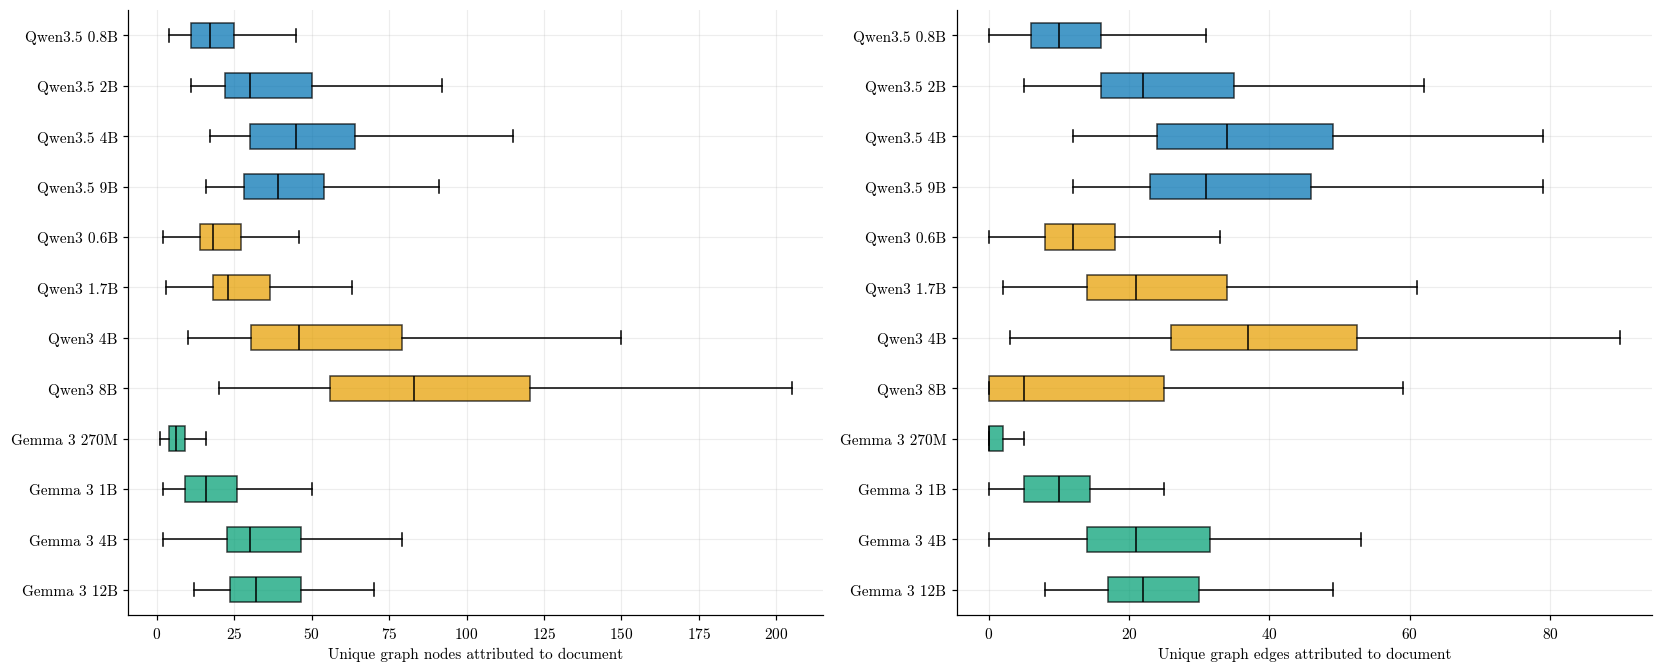

PosixPath('analysis/4.1 Native Graph Construction/Outputs/figures/10_document_provenance.png')

In [15]:
document_rows = []
for key in builder_order:
    node_counts = graphs[key]["nodes"][["node_id", "document_ids"]].explode("document_ids")
    node_counts = node_counts.dropna(subset=["document_ids"]).groupby("document_ids")["node_id"].nunique()
    edge_counts = graphs[key]["edges"][["edge_id", "document_ids"]].explode("document_ids")
    edge_counts = edge_counts.dropna(subset=["document_ids"]).groupby("document_ids")["edge_id"].nunique()
    document_ids = sorted(set(node_counts.index) | set(edge_counts.index))
    for document_id in document_ids:
        document_rows.append({
            "builder_key": key,
            "document_id": document_id,
            "entities": int(node_counts.get(document_id, 0)),
            "relations": int(edge_counts.get(document_id, 0)),
        })

document_coverage = pd.DataFrame(document_rows)
document_summary = document_coverage.groupby("builder_key").agg(
    documents=("document_id", "nunique"),
    entity_mentions_mean=("entities", "mean"),
    entity_mentions_median=("entities", "median"),
    entity_mentions_min=("entities", "min"),
    entity_mentions_max=("entities", "max"),
    relations_mean=("relations", "mean"),
    relations_median=("relations", "median"),
    relations_min=("relations", "min"),
    relations_max=("relations", "max"),
).reindex(builder_order).reset_index()
display(document_summary.style.format({c: "{:.2f}" for c in document_summary.columns if c not in ["builder_key", "documents"]}))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
entity_box = [document_coverage.loc[document_coverage["builder_key"] == key, "entities"] for key in builder_order]
relation_box = [document_coverage.loc[document_coverage["builder_key"] == key, "relations"] for key in builder_order]
box_colors = [FAMILY_COLORS[graphs[key]["family"]] for key in builder_order]
model_labels = [graphs[key]["model"] for key in builder_order]
entity_bp = axes[0].boxplot(entity_box, tick_labels=model_labels, vert=False, showfliers=False, patch_artist=True)
relation_bp = axes[1].boxplot(relation_box, tick_labels=model_labels, vert=False, showfliers=False, patch_artist=True)
style_boxplot(entity_bp, box_colors)
style_boxplot(relation_bp, box_colors)
axes[0].invert_yaxis(); axes[1].invert_yaxis()
axes[0].set_xlabel("Unique graph nodes attributed to document")
axes[1].set_xlabel("Unique graph edges attributed to document")
save_figure(fig, "10_document_provenance.png")

## 12. Relation weights и provenance multiplicity

,builder_key,weight_mean,weight_median,weight_p95,weight_max,multi_document_edge_share,multi_chunk_edge_share
0,qwen35_0_8b,3.174,1.000,15.000,68.000,2.7%,3.9%
1,qwen35_2b,1.414,1.000,2.000,59.000,2.8%,4.3%
2,qwen35_4b,1.130,1.000,2.000,22.000,3.8%,6.7%
3,qwen35_9b,1.126,1.000,2.000,18.000,4.2%,8.0%
4,qwen3_0_6b,1.291,1.000,2.000,73.000,2.1%,3.1%
5,qwen3_1_7b,2.427,1.000,6.000,215.000,2.2%,3.6%
6,qwen3_4b,1.165,1.000,2.000,30.000,2.9%,5.2%
7,qwen3_8b,1.135,1.000,2.000,14.000,1.4%,2.7%
8,gemma3_270m,1.127,1.000,2.000,7.000,5.1%,5.1%
9,gemma3_1b,1.317,1.000,3.000,18.000,3.2%,4.6%


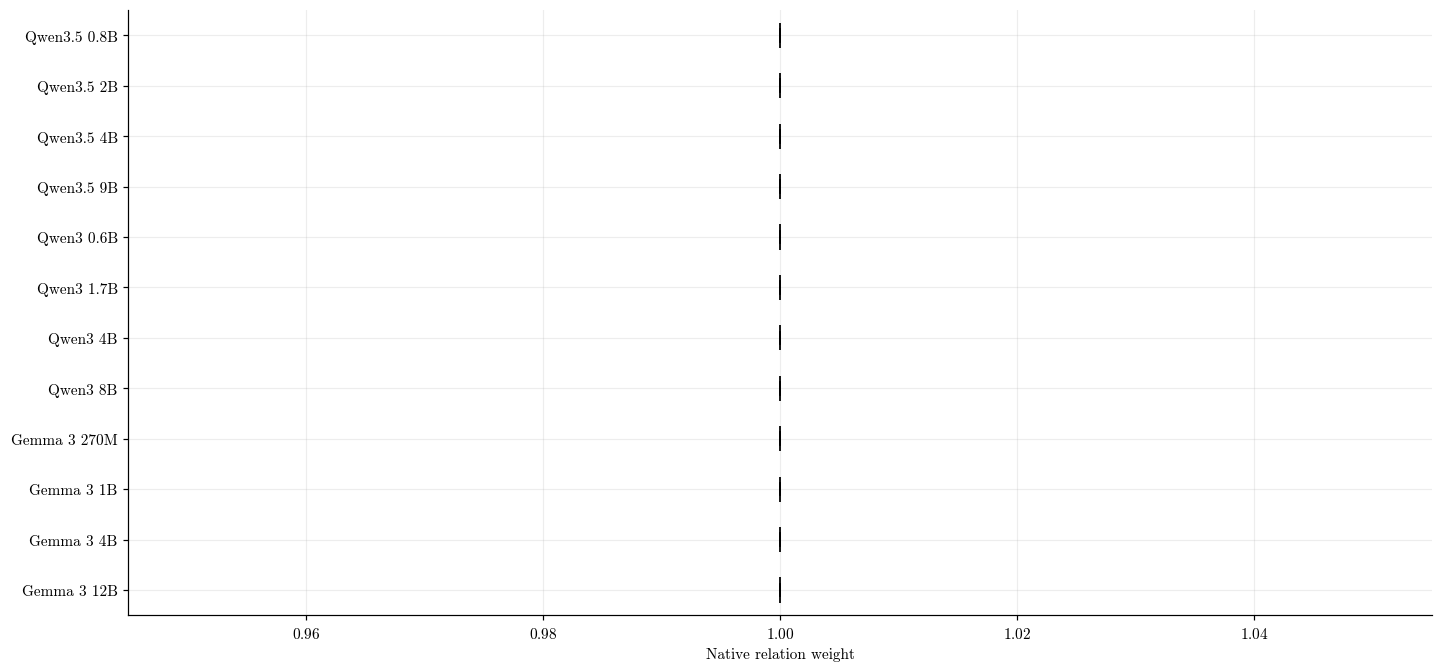

PosixPath('analysis/4.1 Native Graph Construction/Outputs/figures/11_relation_weights.png')

In [16]:
relation_rows = []
for key in builder_order:
    edges = graphs[key]["edges"]
    relation_rows.append({
        "builder_key": key,
        "weight_mean": edges["weight"].mean(),
        "weight_median": edges["weight"].median(),
        "weight_p95": edges["weight"].quantile(0.95),
        "weight_max": edges["weight"].max(),
        "multi_document_edge_share": edges["document_count"].gt(1).mean(),
        "multi_chunk_edge_share": edges["chunk_count"].gt(1).mean(),
    })

relation_stats = pd.DataFrame(relation_rows).set_index("builder_key").loc[builder_order].reset_index()
display(relation_stats.style.format({
    "weight_mean": "{:.3f}", "weight_median": "{:.3f}", "weight_p95": "{:.3f}", "weight_max": "{:.3f}",
    "multi_document_edge_share": "{:.1%}", "multi_chunk_edge_share": "{:.1%}",
}))

fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
weight_data = [graphs[key]["edges"]["weight"] for key in builder_order]
weight_bp = ax.boxplot(weight_data, tick_labels=[graphs[key]["model"] for key in builder_order], vert=False, showfliers=False, patch_artist=True)
style_boxplot(weight_bp, [FAMILY_COLORS[graphs[key]["family"]] for key in builder_order])
ax.invert_yaxis()
ax.set_xlabel("Native relation weight")
save_figure(fig, "11_relation_weights.png")

## 13. Pairwise similarity table и семейные агрегаты

Таблица ниже удобна для последующего цитирования чисел: diagonal исключена, а pairwise similarities представлены один раз на пару.

In [17]:
pairwise_rows = []
for left, right in combinations(builder_order, 2):
    pairwise_rows.append({
        "left": left,
        "right": right,
        "left_family": graphs[left]["family"],
        "right_family": graphs[right]["family"],
        "same_family": graphs[left]["family"] == graphs[right]["family"],
        "node_jaccard": node_jaccard.loc[left, right],
        "edge_jaccard": edge_jaccard.loc[left, right],
        "shared_nodes": len(node_sets[left] & node_sets[right]),
        "shared_edges": len(edge_sets[left] & edge_sets[right]),
    })

pairwise_similarity = pd.DataFrame(pairwise_rows).sort_values(
    ["node_jaccard", "edge_jaccard"], ascending=False
).reset_index(drop=True)
display(pairwise_similarity.style.format({"node_jaccard": "{:.3f}", "edge_jaccard": "{:.3f}"}))

family_similarity = pairwise_similarity.groupby("same_family").agg(
    pairs=("left", "size"),
    mean_node_jaccard=("node_jaccard", "mean"),
    median_node_jaccard=("node_jaccard", "median"),
    mean_edge_jaccard=("edge_jaccard", "mean"),
    median_edge_jaccard=("edge_jaccard", "median"),
).rename(index={False: "different family", True: "same family"})
display(Markdown("**Within-family vs cross-family similarity:**"))
display(family_similarity.style.format({c: "{:.3f}" for c in family_similarity.columns if c != "pairs"}))

,left,right,left_family,right_family,same_family,node_jaccard,edge_jaccard,shared_nodes,shared_edges
0,qwen35_4b,qwen35_9b,qwen3.5,qwen3.5,True,0.598,0.274,5043,2654
1,qwen35_9b,gemma3_12b,qwen3.5,gemma3,False,0.556,0.228,4101,1912
2,qwen35_4b,gemma3_12b,qwen3.5,gemma3,False,0.508,0.210,4151,1819
3,gemma3_4b,gemma3_12b,gemma3,gemma3,True,0.484,0.172,3419,1227
4,qwen35_9b,gemma3_4b,qwen3.5,gemma3,False,0.451,0.158,3617,1389
5,qwen35_2b,gemma3_12b,qwen3.5,gemma3,False,0.449,0.143,3384,1111
6,qwen35_2b,qwen35_9b,qwen3.5,qwen3.5,True,0.446,0.149,3724,1399
7,qwen35_2b,qwen35_4b,qwen3.5,qwen3.5,True,0.438,0.144,3933,1380
8,qwen35_4b,gemma3_4b,qwen3.5,gemma3,False,0.426,0.157,3731,1409
9,qwen35_9b,qwen3_4b,qwen3.5,qwen3,False,0.425,0.167,4163,1849


**Within-family vs cross-family similarity:**

,pairs,mean_node_jaccard,median_node_jaccard,mean_edge_jaccard,median_edge_jaccard
same_family,,,,,
different family,48,0.290,0.292,0.078,0.063
same family,18,0.300,0.306,0.084,0.063


## 14. Экспорт воспроизводимых таблиц

In [18]:
exports = {
    "graph_summary.csv": summary,
    "integrity_checks.csv": quality,
    "degree_statistics.csv": degree_stats,
    "entity_type_shares.csv": type_shares.reset_index(),
    "node_jaccard.csv": node_jaccard.reset_index(names="builder_key"),
    "edge_jaccard.csv": edge_jaccard.reset_index(names="builder_key"),
    "pairwise_similarity.csv": pairwise_similarity,
    "entity_consensus.csv": consensus,
    "entity_type_disagreements.csv": type_disagreements,
    "document_provenance_summary.csv": document_summary,
    "relation_statistics.csv": relation_stats,
    f"top_hubs_{SELECTED_BUILDER}.csv": hubs,
}

for filename, dataframe in exports.items():
    dataframe.to_csv(TABLES_DIR / filename, index=False)

export_index = pd.DataFrame({
    "file": list(exports),
    "rows": [len(df) for df in exports.values()],
    "path": [str(TABLES_DIR / filename) for filename in exports],
})
display(export_index)
print(f"Saved {len(exports)} tables and {len(list(FIGURES_DIR.glob('*.png')))} figures to {OUTPUT_DIR}")

,file,rows,path
0,graph_summary.csv,12,analysis/4.1 Native Graph Constru...
1,integrity_checks.csv,12,analysis/4.1 Native Graph Constru...
2,degree_statistics.csv,12,analysis/4.1 Native Graph Constru...
3,entity_type_shares.csv,12,analysis/4.1 Native Graph Constru...
4,node_jaccard.csv,12,analysis/4.1 Native Graph Constru...
5,edge_jaccard.csv,12,analysis/4.1 Native Graph Constru...
6,pairwise_similarity.csv,66,analysis/4.1 Native Graph Constru...
7,entity_consensus.csv,22264,analysis/4.1 Native Graph Constru...
8,entity_type_disagreements.csv,5365,analysis/4.1 Native Graph Constru...
9,document_provenance_summary.csv,12,analysis/4.1 Native Graph Constru...


Saved 12 tables and 10 figures to analysis/4.1 Native Graph Construction/Outputs


## Как интерпретировать результаты

- **Nodes / edges** показывают extraction volume, но сами по себе не являются quality score.
- **Largest component, isolates, degree и transitivity** описывают связанность и topology Native graph.
- **Entity-type composition** показывает, насколько по-разному builders следуют одной и той же extraction schema.
- **Node/edge Jaccard** измеряет только exact normalized label agreement; низкое значение может отражать aliases, granularity или extraction omissions.
- **Consensus и type disagreements** дают конкретные candidates для качественного разбора и последующего сравнения с corpus-level ER.
- **Document provenance distributions** помогают увидеть, какие builders извлекают более плотные или более разреженные структуры из одного и того же корпуса.

Для thesis conclusions следует связывать эти descriptive graph differences с downstream Native QA и paired Native-vs-ER evaluation отдельно: структура графа не заменяет task-level quality measurement.